<a href="https://colab.research.google.com/github/Sosswood/Machine-Learning/blob/main/Unit02_Auto_mpg_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

In [3]:
df=pd.read_csv("Unit02 auto-mpg (1).csv")

In [7]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [8]:
df.describe ()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [10]:
df.head (10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [11]:
df.tail (10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
388,26.0,4,156.0,92,2585,14.5,82,1,chrysler lebaron medallion
389,22.0,6,232.0,112,2835,14.7,82,1,ford granada l
390,32.0,4,144.0,96,2665,13.9,82,3,toyota celica gt
391,36.0,4,135.0,84,2370,13.0,82,1,dodge charger 2.2
392,27.0,4,151.0,90,2950,17.3,82,1,chevrolet camaro
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


In [12]:
numeric_features = df.select_dtypes(include=[np.number])

numeric_features.columns

Index(['mpg', 'cylinders', 'displacement', 'weight', 'acceleration',
       'model year', 'origin'],
      dtype='object')

In [13]:
categorical_features = df.select_dtypes(include=[object])
categorical_features.columns

Index(['horsepower', 'car name'], dtype='object')

<Axes: >

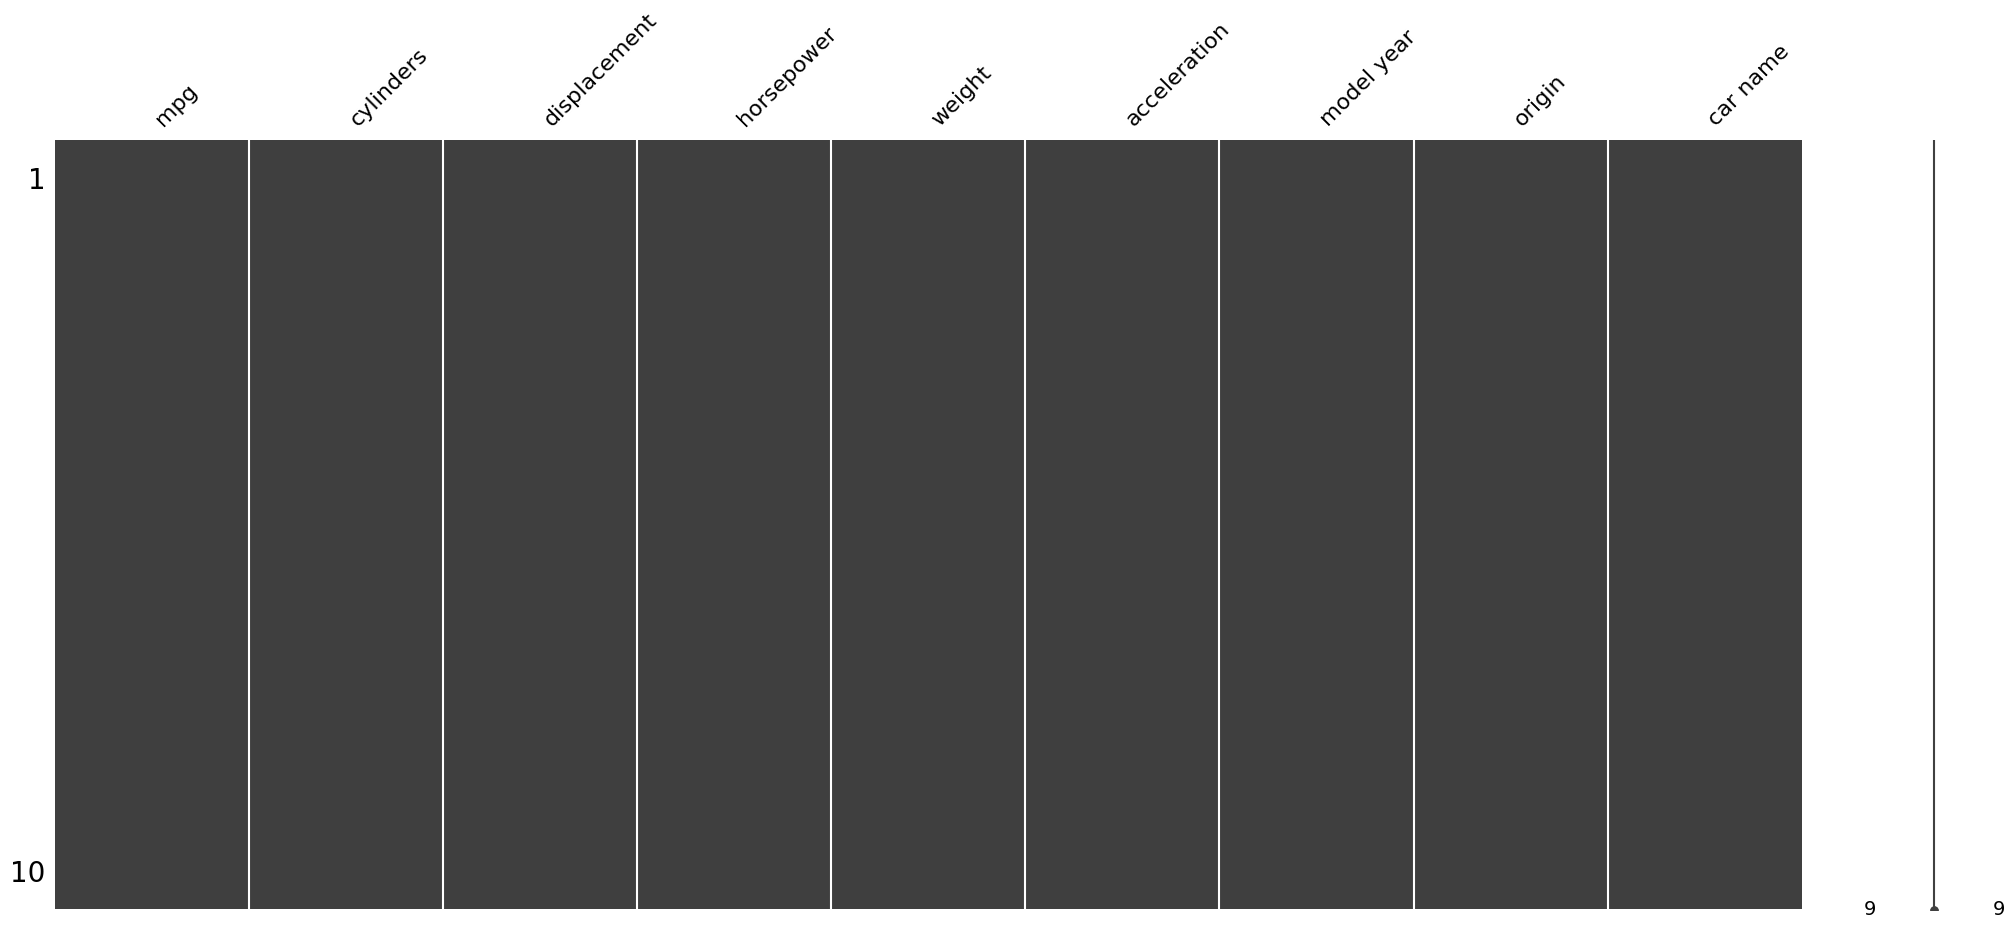

In [15]:
msno.matrix(df.sample(10))

/usr/local/lib/python3.13/dist-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/usr/local/lib/python3.13/dist-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


<Axes: >

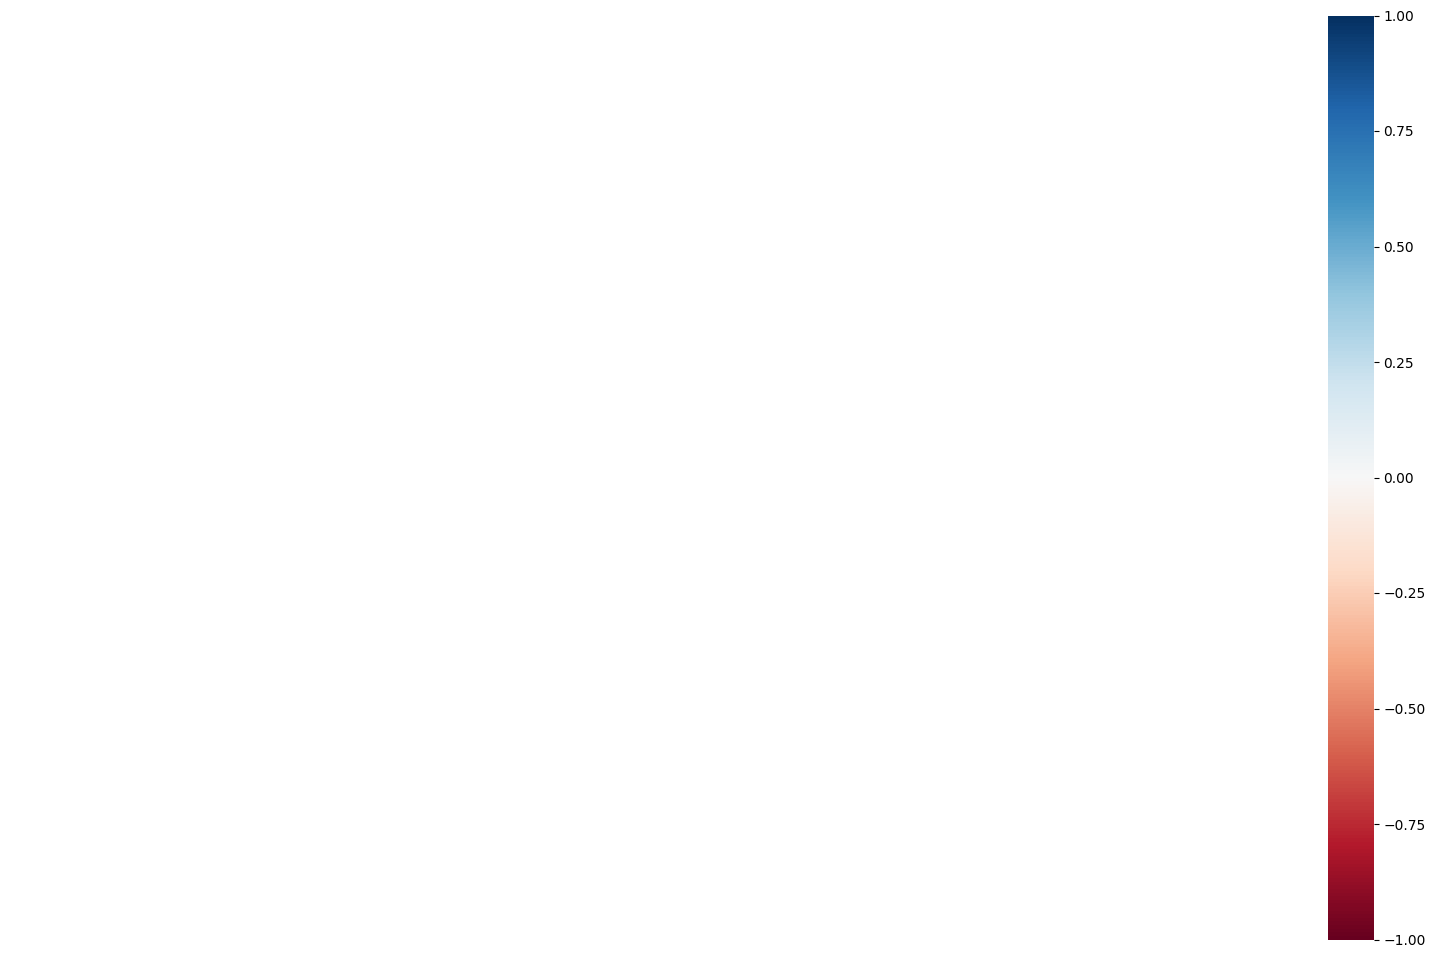

In [16]:
msno.heatmap(df)

In [17]:
numeric_features.skew(), numeric_features.kurt()

(mpg             0.457066
 cylinders       0.526922
 displacement    0.719645
 weight          0.531063
 acceleration    0.278777
 model year      0.011535
 origin          0.923776
 dtype: float64,
 mpg            -0.510781
 cylinders      -1.376662
 displacement   -0.746597
 weight         -0.785529
 acceleration    0.419497
 model year     -1.181232
 origin         -0.817597
 dtype: float64)

/tmp/ipykernel_2161/3442137212.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y, kde=False, fit=st.johnsonsu)
/tmp/ipykernel_2161/3442137212.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y, kde=False, fit=st.norm)
/tmp/ipykernel_2161/3442137212.py:7: UserWarning: 

`distplot` is a dep

<Axes: title={'center': 'Log Normal'}, xlabel='mpg'>

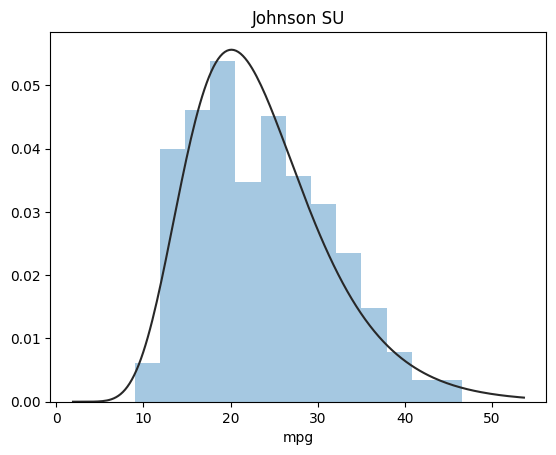

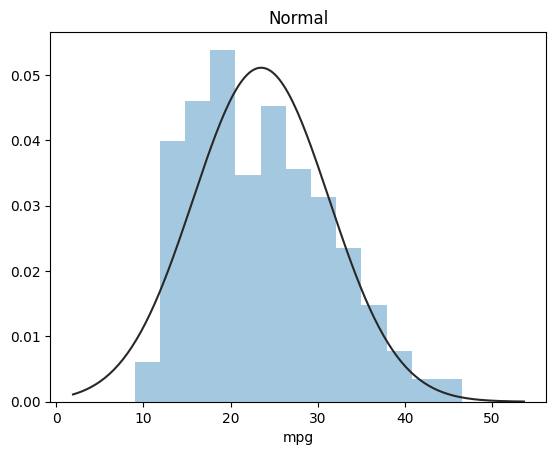

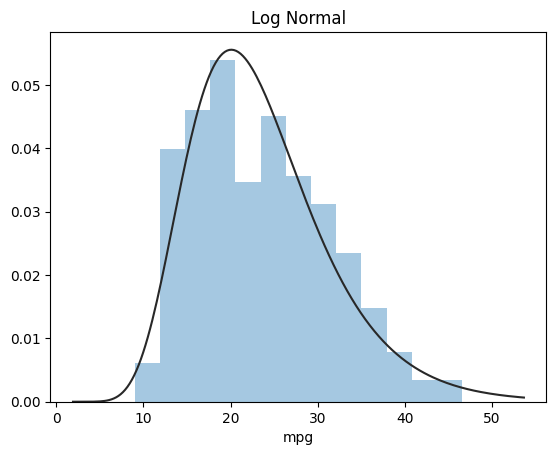

In [19]:
y = df['mpg']
plt.figure(1); plt.title('Johnson SU')
sns.distplot(y, kde=False, fit=st.johnsonsu)
plt.figure(2); plt.title('Normal')
sns.distplot(y, kde=False, fit=st.norm)
plt.figure(3); plt.title('Log Normal')
sns.distplot(y, kde=False, fit=st.lognorm)

Text(0.5, 0, 'Skewness')

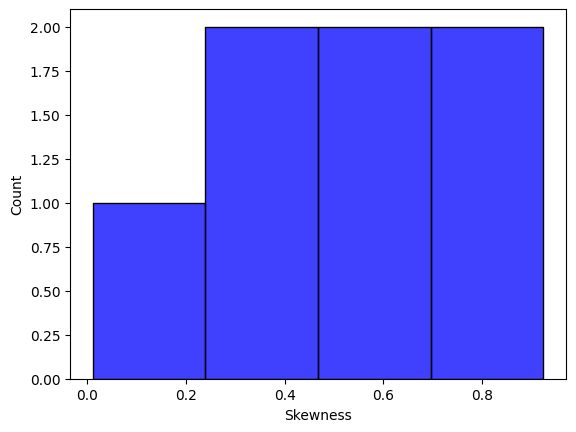

In [20]:
ax = sns.histplot(numeric_features.skew(), color='blue')
ax.set_xlabel('Skewness')

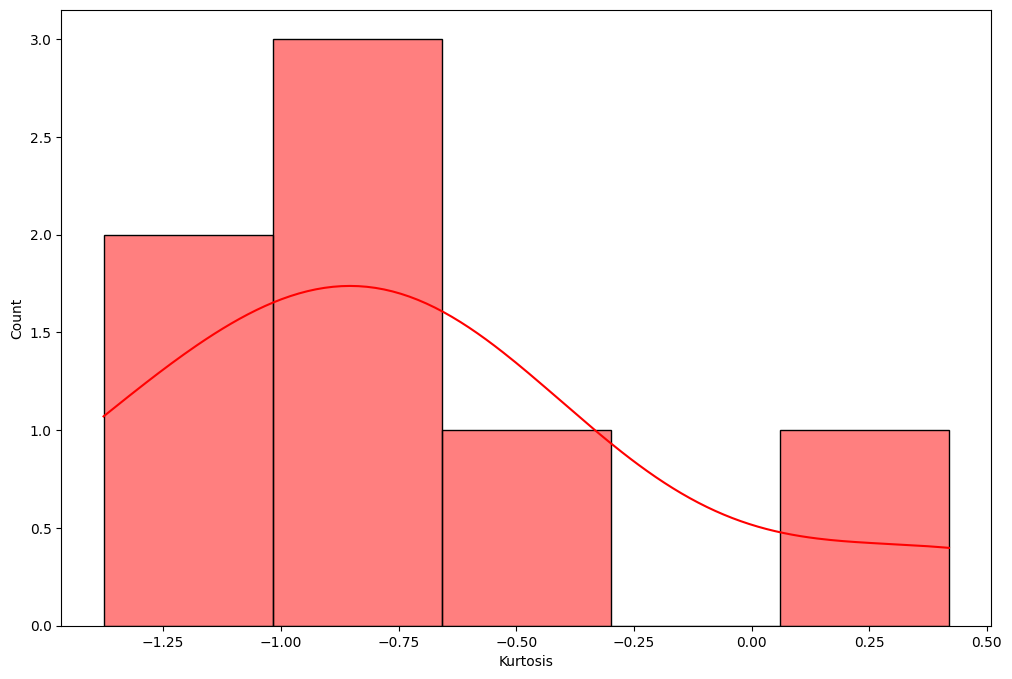

In [21]:
plt.figure(figsize = (12,8))
ax = sns.histplot(numeric_features.kurt(), color='r', kde = True)
ax.set_xlabel('Kurtosis')
plt.show()

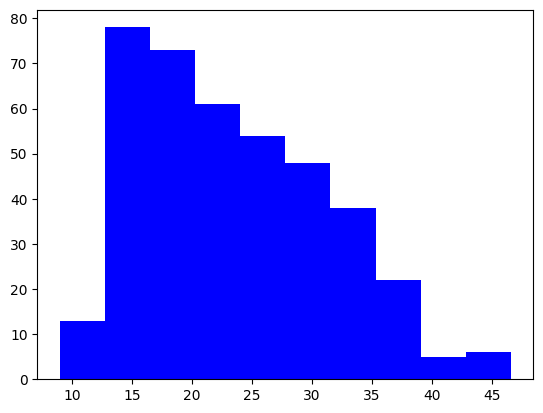

In [23]:
plt.hist(df['mpg'],orientation = 'vertical',histtype = 'bar', color ='blue')
plt.show()

(array([ 3., 10., 40., 46., 66., 60., 67., 58., 39.,  9.]),
 array([2.19722458, 2.36166217, 2.52609977, 2.69053737, 2.85497496,
        3.01941256, 3.18385016, 3.34828775, 3.51272535, 3.67716294,
        3.84160054]),
 <BarContainer object of 10 artists>)

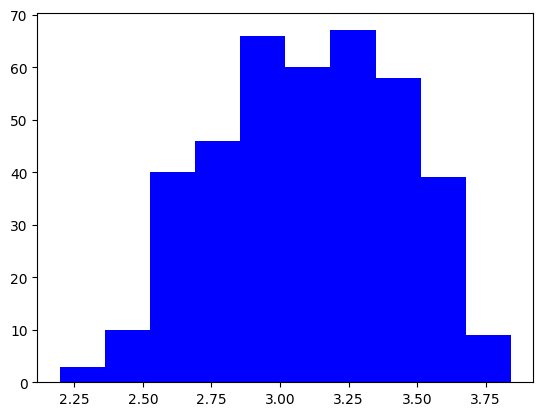

In [24]:
target = np.log(df['mpg'])
target.skew()
plt.hist(target,color='blue')

In [26]:
correlation = numeric_features.corr()
print(correlation['mpg'].sort_values(ascending = False),'\n')

mpg             1.000000
model year      0.579267
origin          0.563450
acceleration    0.420289
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64 



<Axes: title={'center': 'Correlation of Numeric Features with MPG'}>

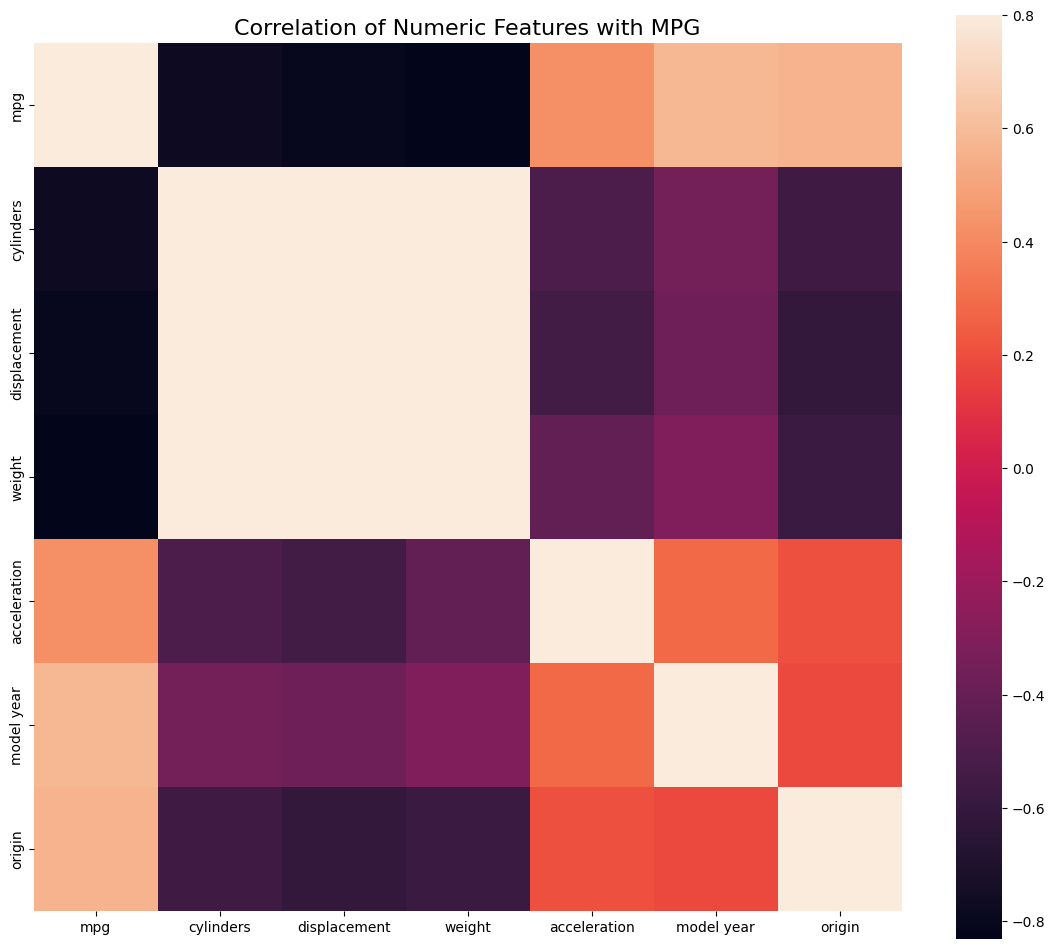

In [27]:
f , ax = plt.subplots(figsize = (14,12))

plt.title('Correlation of Numeric Features with MPG',y=1,size=16)

sns.heatmap(correlation,square = True,  vmax=0.8)

Index(['mpg', 'model year', 'origin', 'acceleration', 'cylinders',
       'displacement', 'weight'],
      dtype='object')


<Axes: >

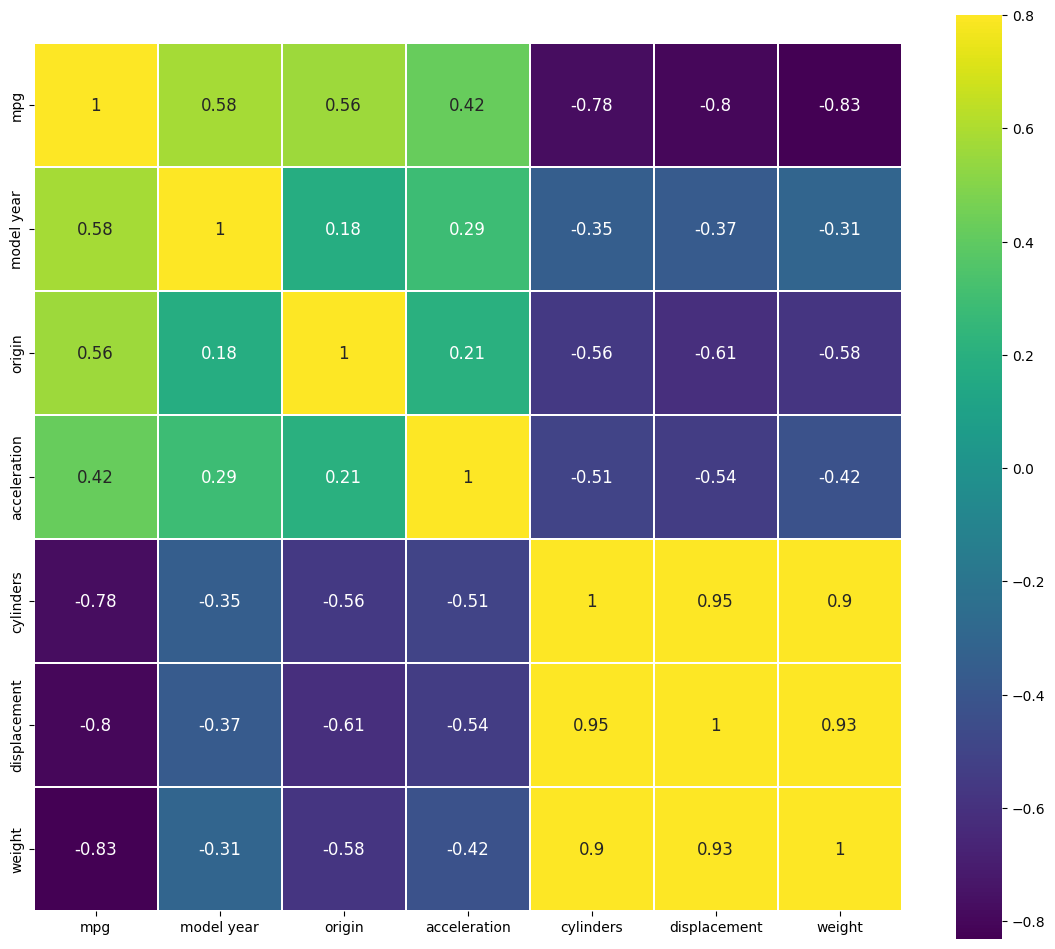

In [28]:
k= 11
cols = correlation.nlargest(k,'mpg')['mpg'].index
print(cols)
cm = np.corrcoef(df[cols].values.T)
f , ax = plt.subplots(figsize = (14,12))
sns.heatmap(cm, vmax=.8, linewidths=0.01,square=True,annot=True,cmap='viridis',
            linecolor="white",xticklabels = cols.values ,annot_kws = {'size':12},yticklabels = cols.values)

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


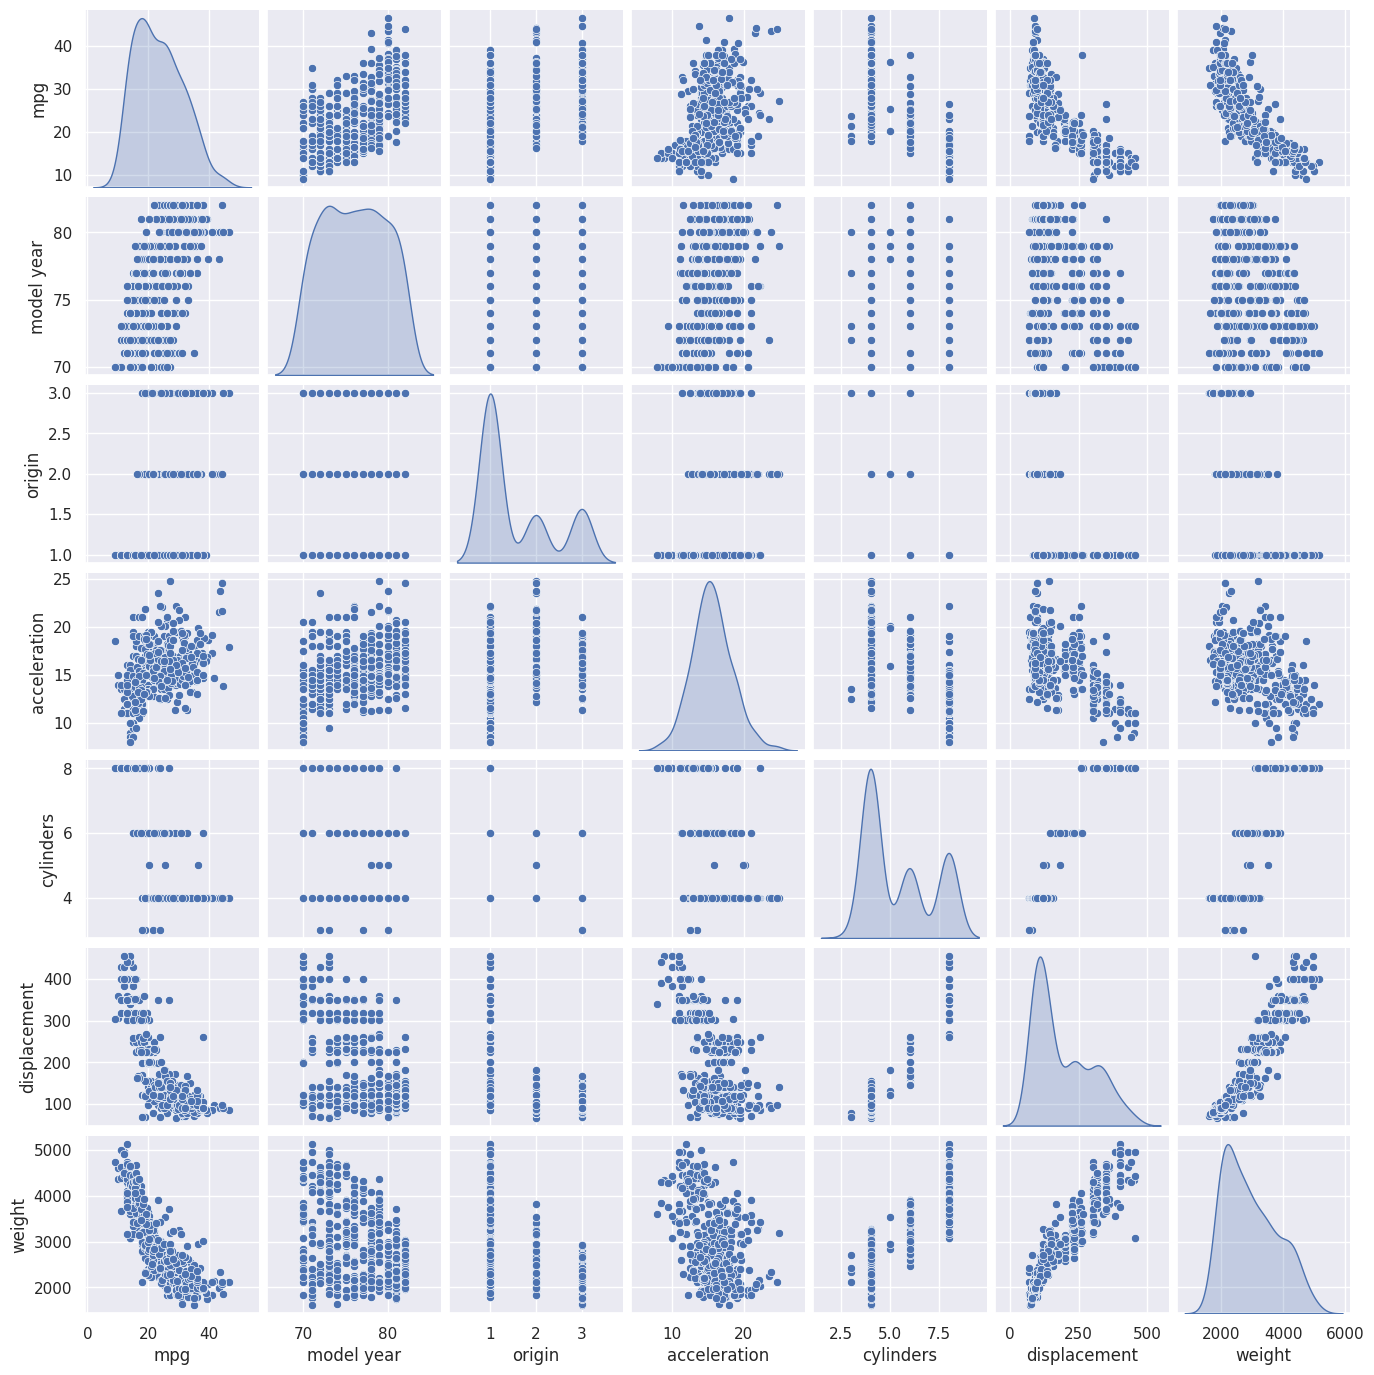

In [29]:
sns.set()
columns = ['mpg','model year','origin','acceleration','cylinders','displacement','weight']
sns.pairplot(df[columns],size = 2 ,kind ='scatter',diag_kind='kde')
plt.show()

<Axes: xlabel='weight', ylabel='mpg'>

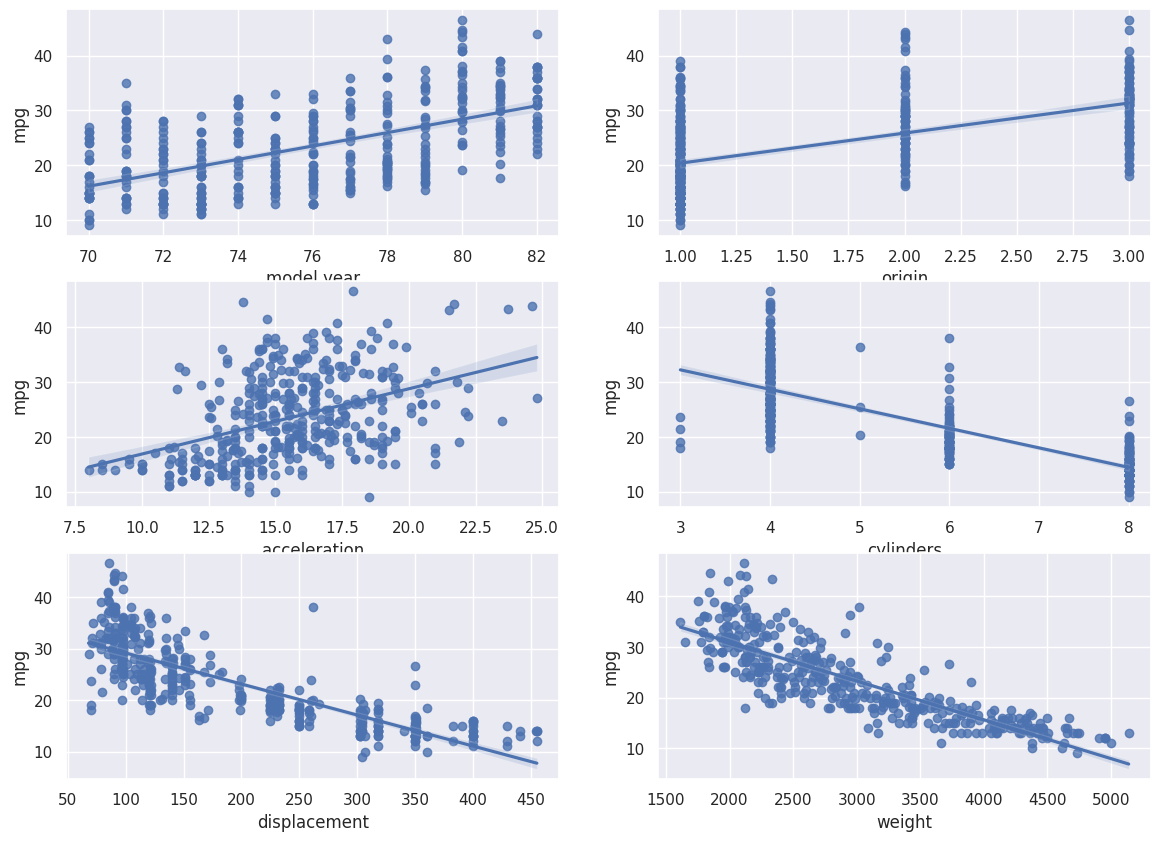

In [31]:
fig, ((ax1, ax2), (ax3, ax4),(ax5,ax6)) = plt.subplots(nrows=3, ncols=2, figsize=(14,10))
model_year_scatter_plot = pd.concat([df['mpg'],df['model year']],axis = 1)
sns.regplot(x='model year',y = 'mpg',data = model_year_scatter_plot,scatter= True, fit_reg=True, ax=ax1)
origin_scatter_plot = pd.concat([df['mpg'],df['origin']],axis = 1)
sns.regplot(x='origin',y = 'mpg',data = origin_scatter_plot,scatter= True, fit_reg=True, ax=ax2)
acceleration_scatter_plot = pd.concat([df['mpg'],df['acceleration']],axis = 1)
sns.regplot(x='acceleration',y = 'mpg',data = acceleration_scatter_plot,scatter= True, fit_reg=True, ax=ax3)
cylinders_scatter_plot = pd.concat([df['mpg'],df['cylinders']],axis = 1)
sns.regplot(x='cylinders',y = 'mpg',data = cylinders_scatter_plot,scatter= True, fit_reg=True, ax=ax4)
displacement_scatter_plot = pd.concat([df['mpg'],df['displacement']],axis = 1)
sns.regplot(x='displacement',y = 'mpg',data = displacement_scatter_plot,scatter= True, fit_reg=True, ax=ax5)
weight_scatter_plot = pd.concat([df['mpg'],df['weight']],axis = 1)
sns.regplot(x='weight',y = 'mpg',data = weight_scatter_plot,scatter= True, fit_reg=True, ax=ax6)

/tmp/ipykernel_2161/2336495863.py:1: FutureWarning: The provided callable <function median at 0x7f38bb7cfba0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  mpg_acceleration= df.pivot_table(index ='acceleration',values = 'mpg', aggfunc = np.median)


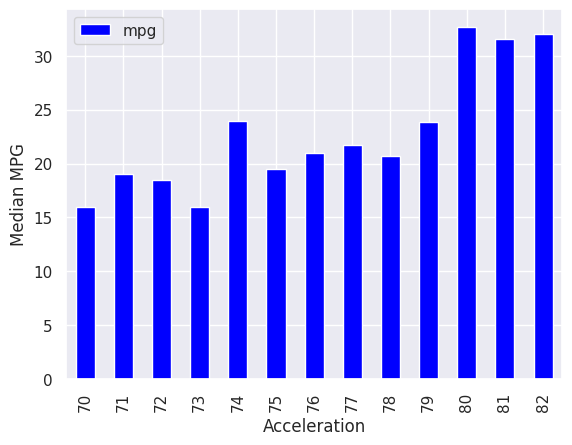

In [37]:
mpg_acceleration= df.pivot_table(index ='acceleration',values = 'mpg', aggfunc = np.median)
mpg_model_year.plot(kind = 'bar',color = 'blue')
plt.xlabel('Acceleration')
plt.ylabel('Median MPG')
plt.show()

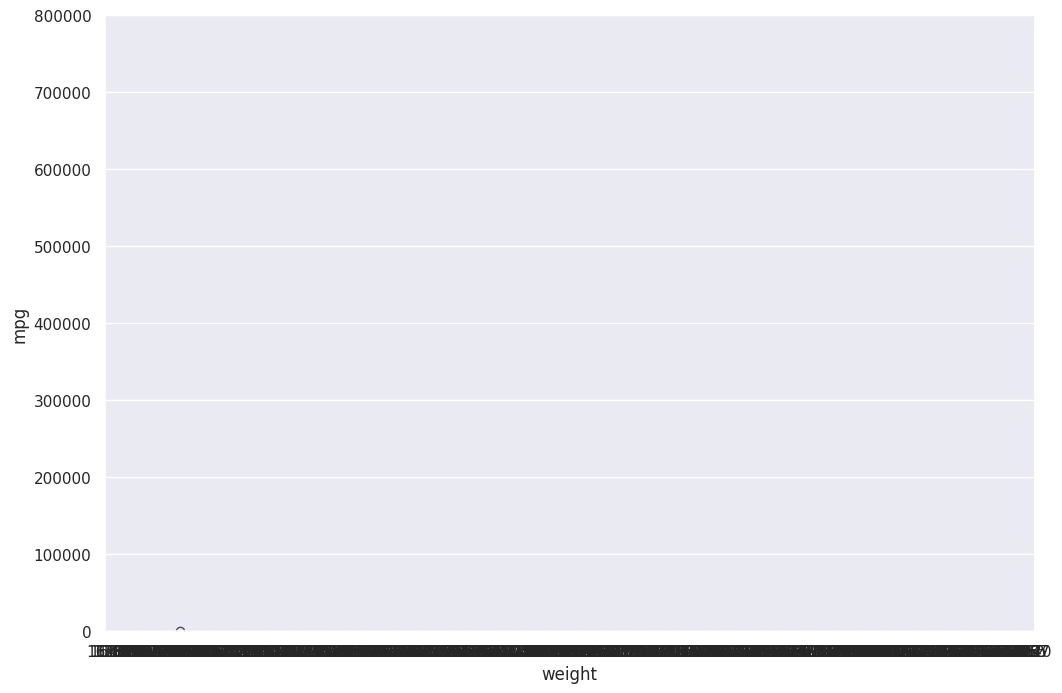

In [39]:
var = 'weight'
data = pd.concat([df['mpg'], df[var]], axis=1)
f, ax = plt.subplots(figsize=(12, 8))
fig = sns.boxplot(x=var, y="mpg", data=data)
fig.axis(ymin=0, ymax=800000);

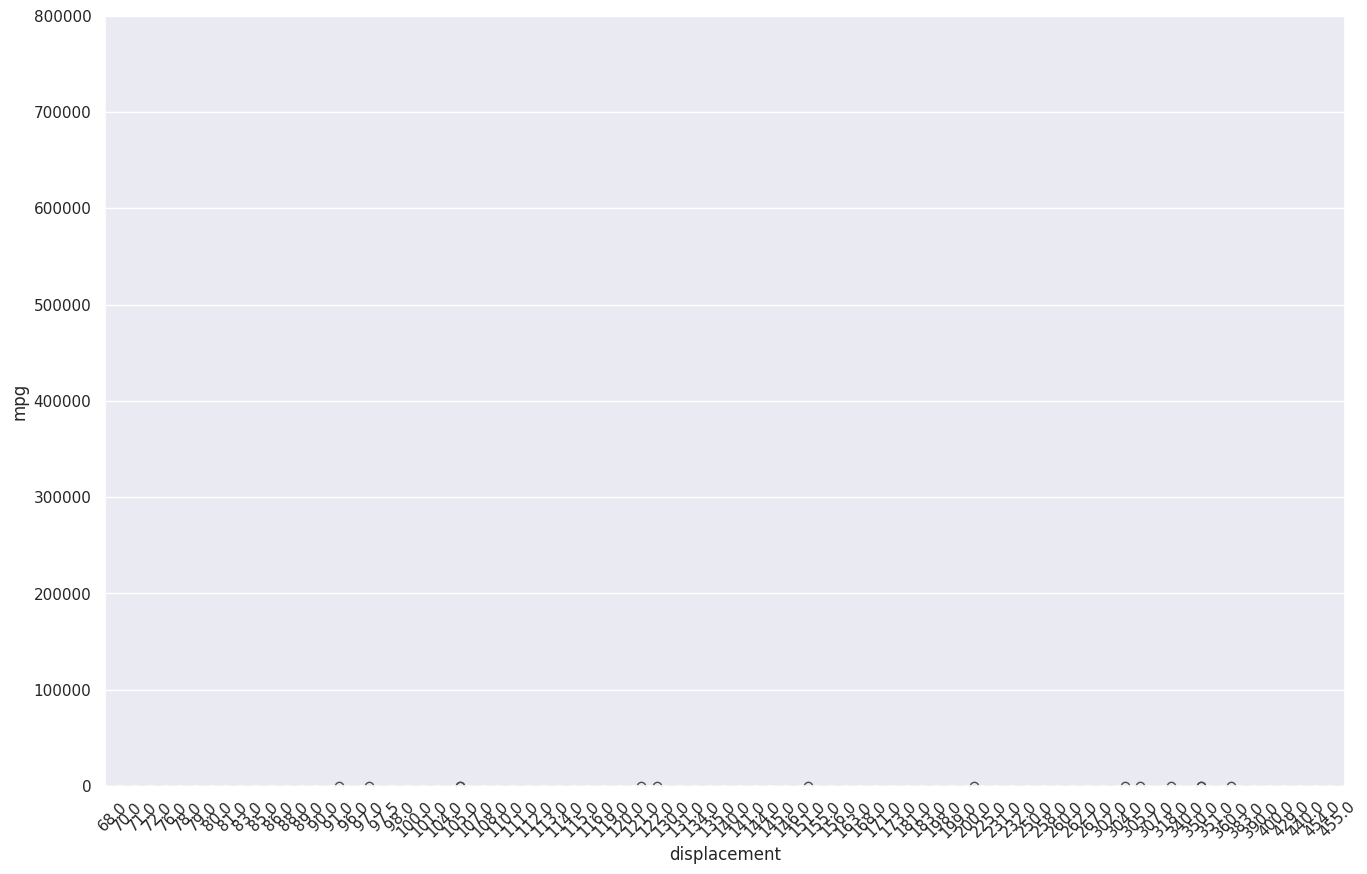

In [40]:
var = 'displacement'
data = pd.concat([df['mpg'], df[var]], axis=1)
f, ax = plt.subplots(figsize=(16, 10))
fig = sns.boxplot(x=var, y="mpg", data=data)
fig.axis(ymin=0, ymax=800000);
xt = plt.xticks(rotation=45)

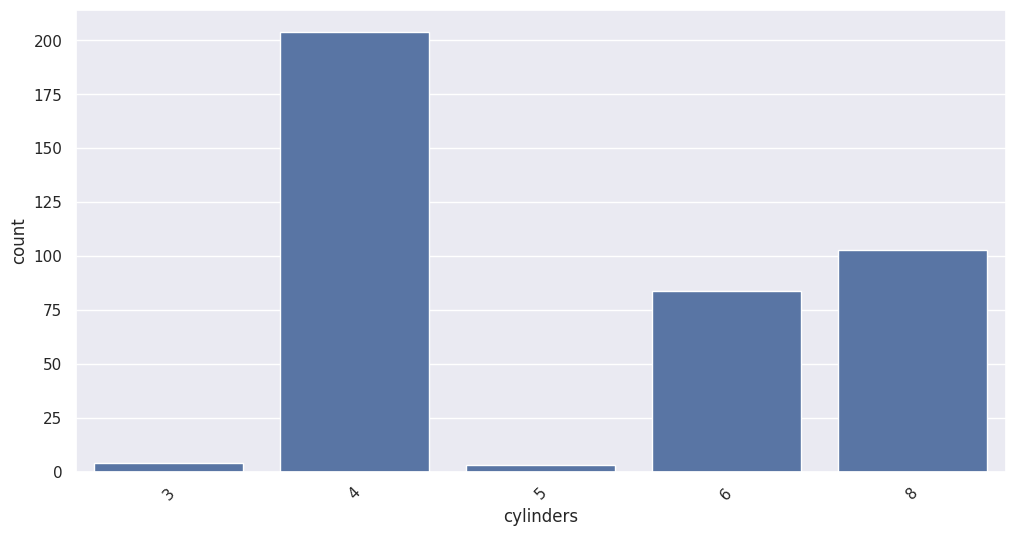

In [42]:
plt.figure(figsize = (12, 6))
sns.countplot(x = 'cylinders', data = df)
xt = plt.xticks(rotation=45)

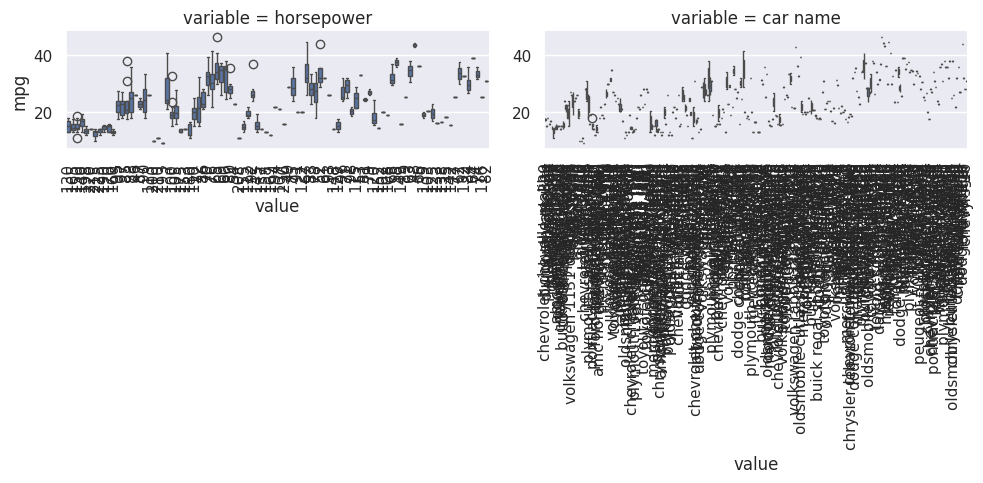

In [43]:
for c in categorical_features:
    df[c] = df[c].astype('category')
    if df[c].isnull().any():
        df[c] = df[c].cat.add_categories(['MISSING'])
        df[c] = df[c].fillna('MISSING')

def boxplot(x, y, **kwargs):
    sns.boxplot(x=x, y=y)
    x=plt.xticks(rotation=90)
f = pd.melt(df, id_vars=['mpg'], value_vars=categorical_features)
g = sns.FacetGrid(f, col="variable",  col_wrap=2, sharex=False, sharey=False, height=5)
g = g.map(boxplot, "value", "mpg")

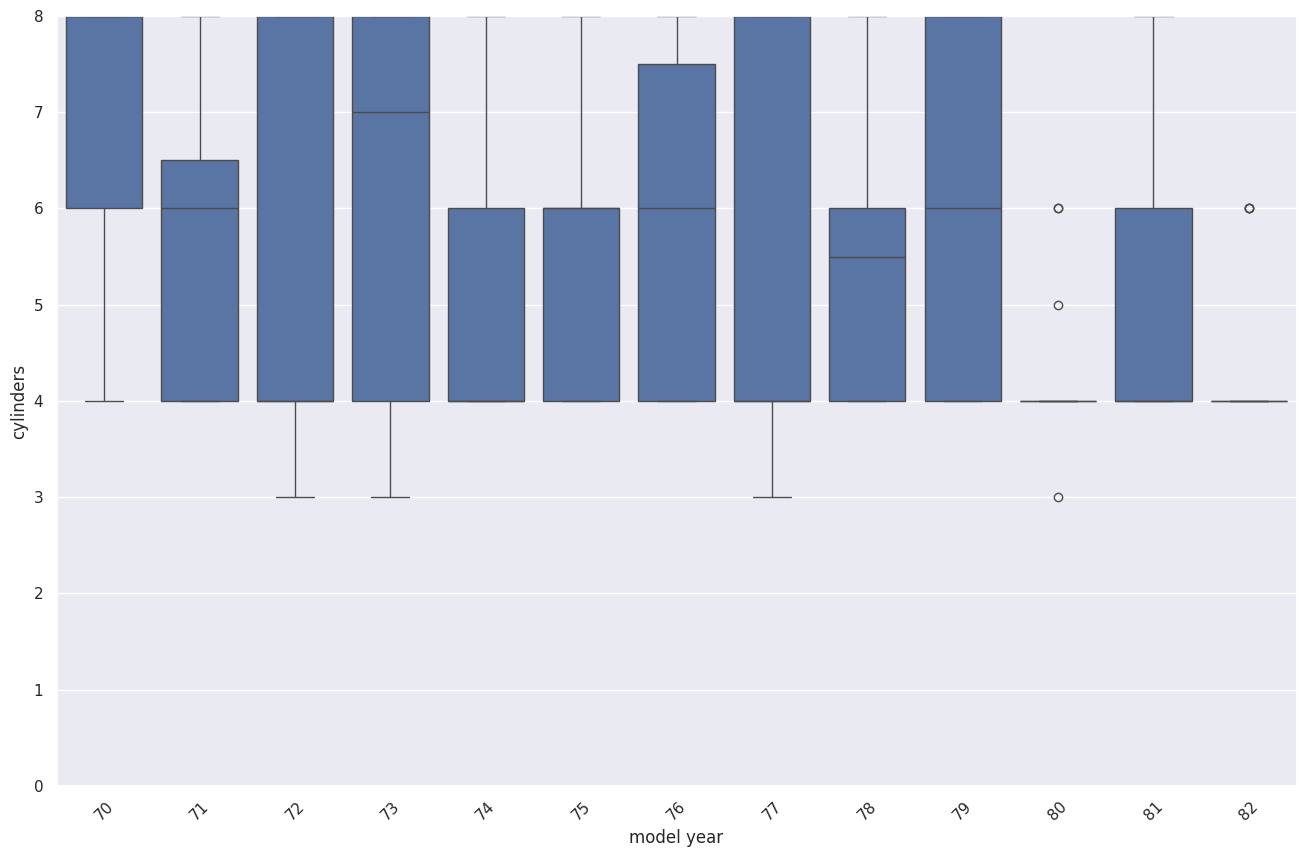

In [58]:
var = 'model year'
data = pd.concat([df['cylinders'], df[var]], axis=1)
f, ax = plt.subplots(figsize=(16, 10))
fig = sns.boxplot(x=var, y="cylinders", data=data)
fig.axis(ymin=0, ymax=8);
xt = plt.xticks(rotation=45)

/tmp/ipykernel_2161/520330157.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g1.set_xticklabels(g1.get_xticklabels(),rotation=90)


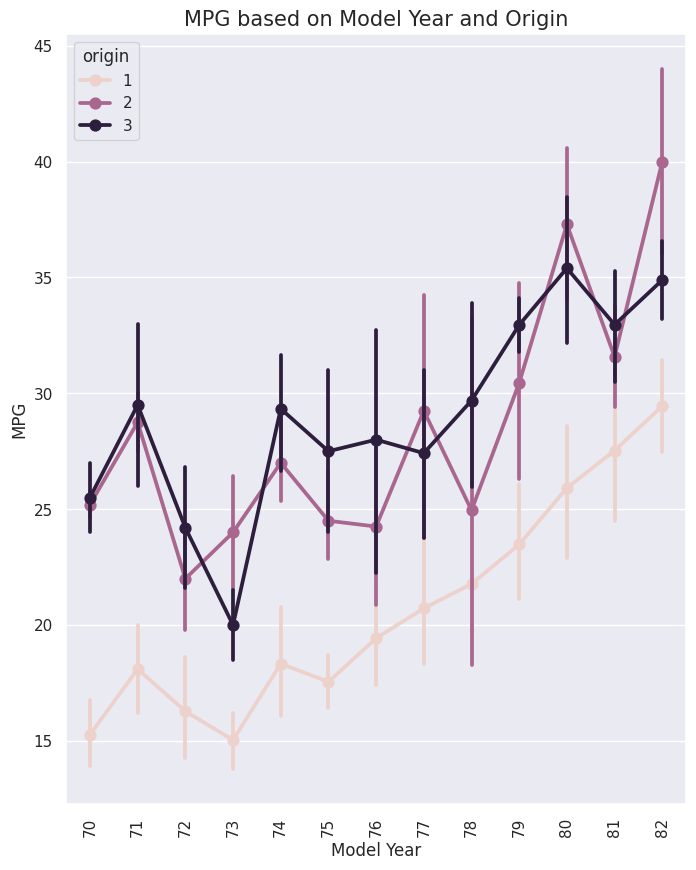

In [57]:
plt.figure(figsize=(8,10))
g1 = sns.pointplot(x='model year', y='mpg',
                   data=df, hue='origin')
g1.set_xticklabels(g1.get_xticklabels(),rotation=90)
g1.set_title("MPG based on Model Year and Origin", fontsize=15)
g1.set_xlabel("Model Year")
g1.set_ylabel("MPG", fontsize=12)
plt.show()

In [60]:
for column_name in df.columns:
    if df[column_name].dtypes == 'object':
        df[column_name] = df[column_name].fillna(df[column_name].mode().iloc[0])
        unique_category = len(df[column_name].unique())
        print("Feature '{column_name}' has '{unique_category}' unique categories".format(column_name = column_name,
                                                                                         unique_category=unique_category))
